In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ

        # optional: avoid negative distance
        if r[i] < 0
            r[i] = 0.0
        end
    end

    return r
end

simulate_OU (generic function with 1 method)

In [22]:
k = 0.043
D = 0.655
dt = 0.01
T = 600
r0 = 42.158 * 2.5
lambda_075 = simulate_OU(k, D, dt, T, r0)

60000-element Vector{Float64}:
 105.39500000000001
 105.33592449352678
 105.3100443438566
 105.32906568793179
 105.34735896947946
 105.20999369608084
 105.1289946400037
 105.05797150634339
 105.09221736299287
 105.0328058504246
   ⋮
   0.10384094320465385
   0.03271261869090737
   0.15795941317137094
   0.1854500080842244
   0.010099455166364957
   0.0884674790271882
   0.3035670502587413
   0.367148077551844
   0.40493828635595275

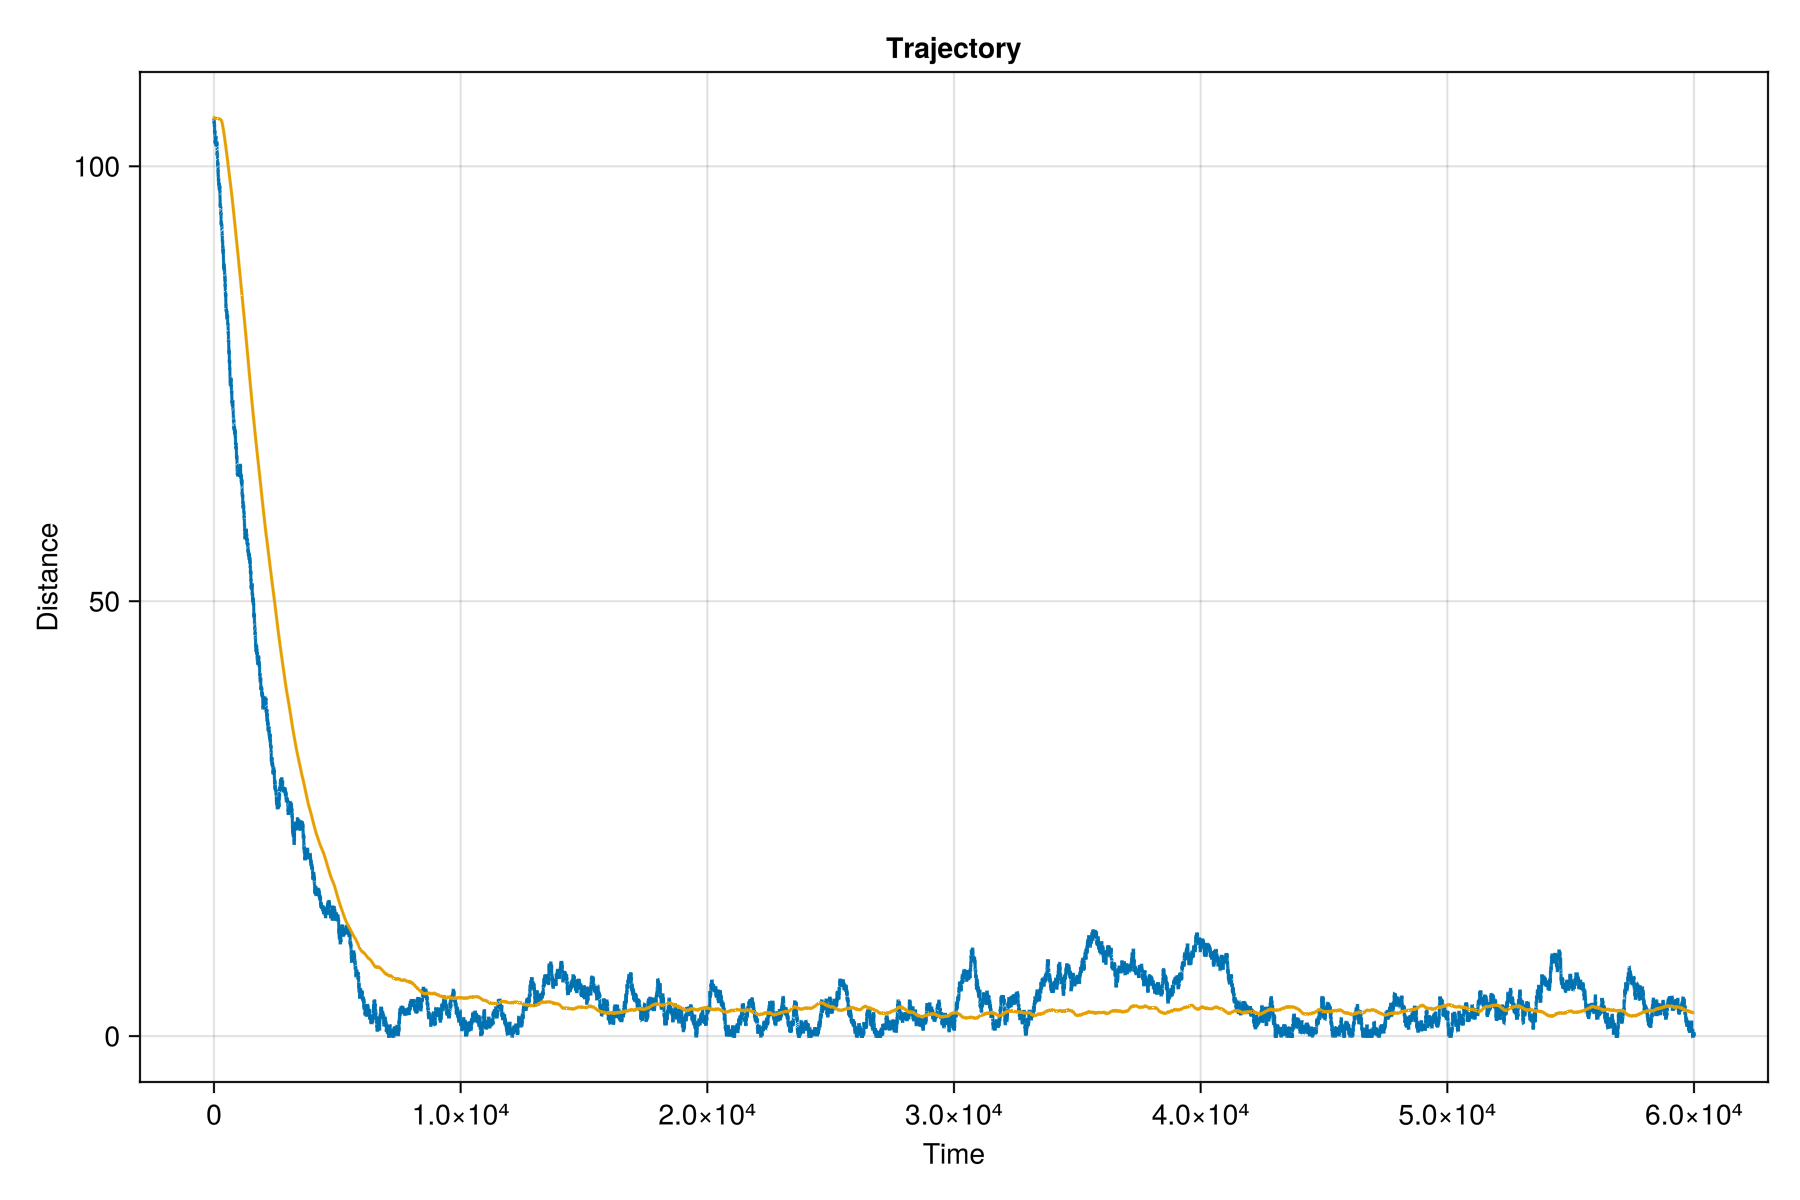

GLMakie.Screen(...)

In [23]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Trajectory", xlabel = "Time", ylabel = "Distance")

lines!(ax, 1:60000, lambda_075)
jldopen("fsb_10.0_lambda_0.75.jld2", "r") do file 
                mean_dist = Float64[]
                for step in 1:60000
                    g = file[@sprintf("step_%06d", step)]
                    # Ensure com.N is defined globally
                    xs = g["x"][1]
                    other_x = g["x"][2:1001]
                    
                    dists_x = other_x .- xs

                    push!(mean_dist, mean(dists_x))
        
                end
                
                # Plot the normalized line
                lines!(ax, 1:60000, mean_dist)
            end
                
display(fig)

In [24]:
save("Plots/Fixed_source_model/OU_ABM_lambda_075.png", fig)

# Separate bimodal populations


Detected 2001 cells.

--- Results ---
Total Cells: 2001
Trapped: 1666 (83.25837081459271%)
Escaped: 335 (16.741629185407298%)
Trapped Mean (μ): 4.03
Trapped Std Dev (σ): 38.53


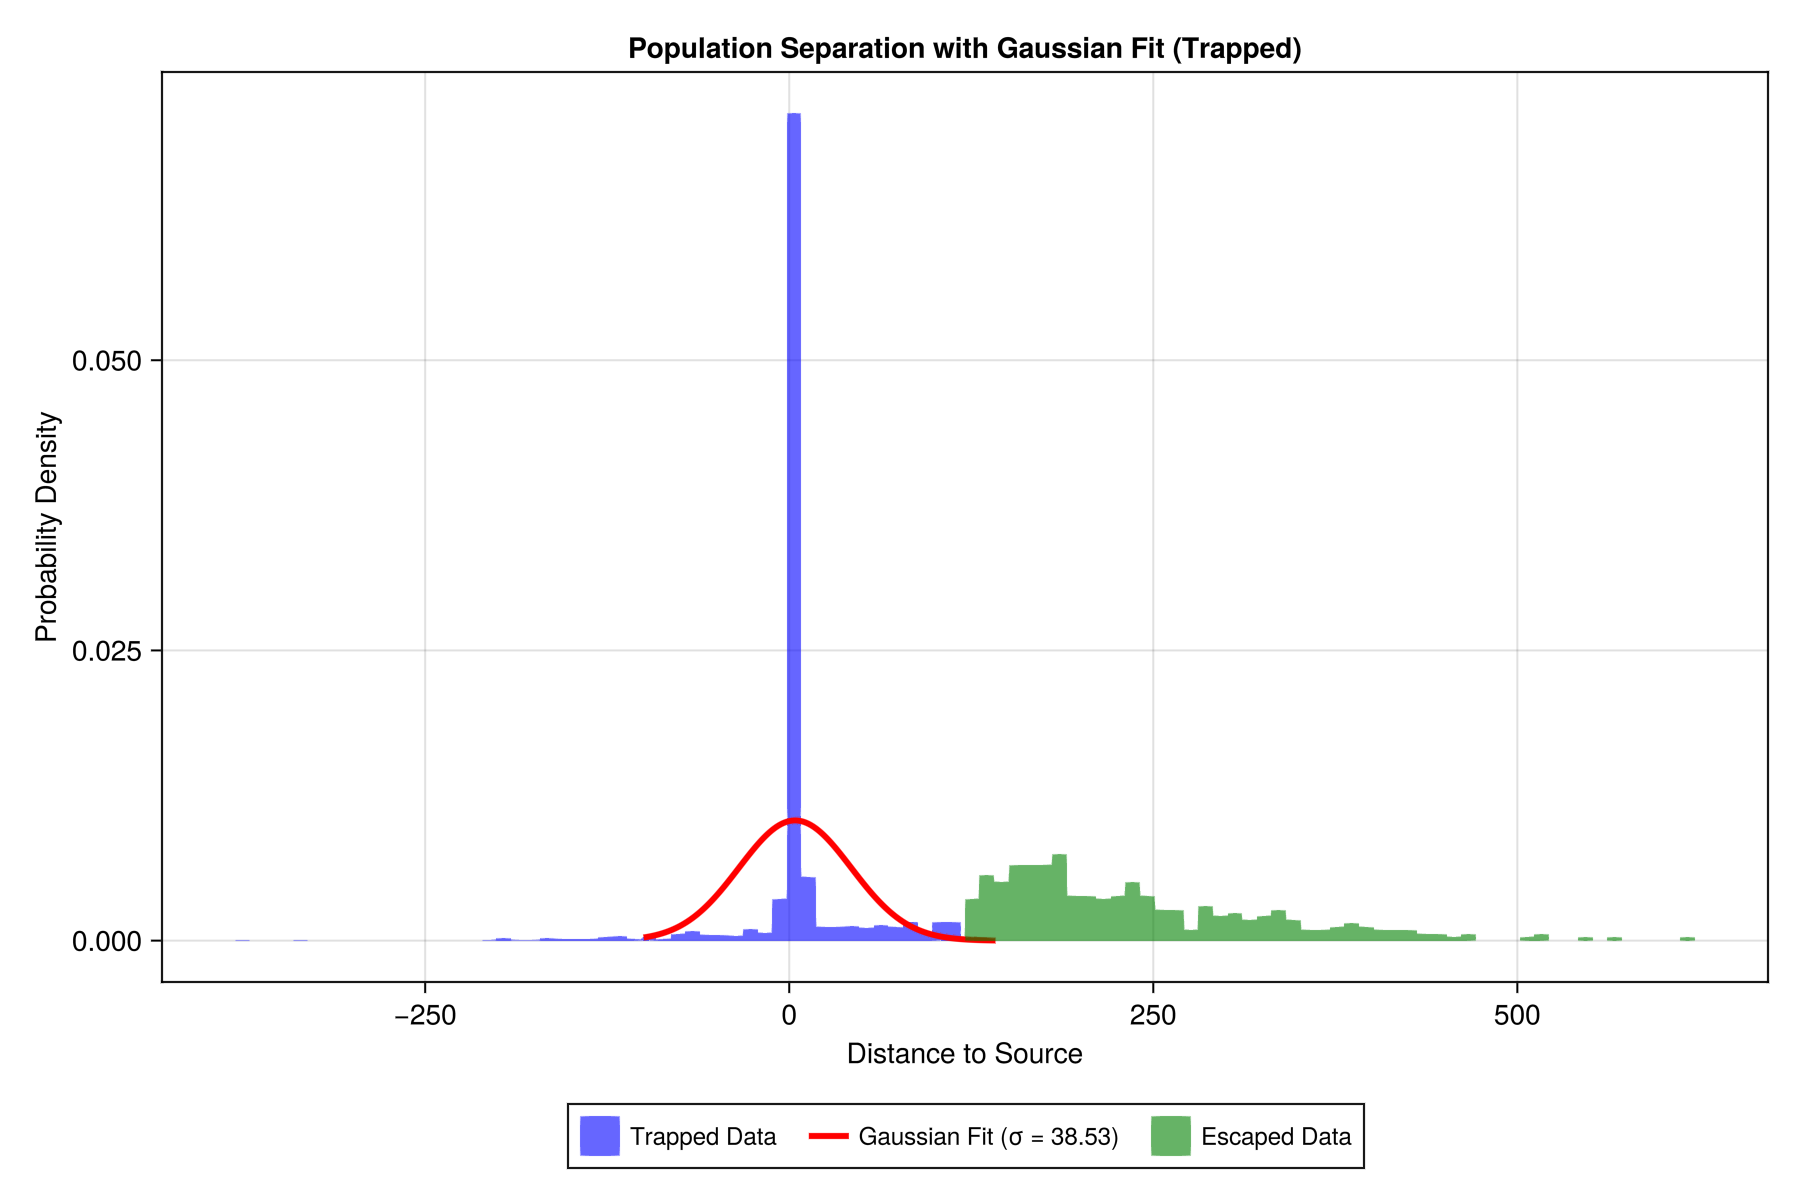

GLMakie.Screen(...)

In [78]:
using Distributions
# Configuration
filename = "fsb_10.0_lambda_10.0.jld2"
steps_total = 60000
steps_to_average = 1000 
D_crit = 120.0 

# Create Figure and Axis
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1],
          title = "Population Separation with Gaussian Fit (Trapped)",
          xlabel = "Distance to Source",
          ylabel = "Probability Density"
)

# --- DATA EXTRACTION & FITTING ---
jldopen(filename, "r") do file
    # 1. Determine number of cells
    g_sample = file["step_000001"]
    total_points = length(g_sample["x"])
    n_cells = total_points - 1
    
    println("Detected $n_cells cells.")

    sums = zeros(Float64, n_cells) 
    
    # 2. Loop through last N steps
    start_step = steps_total - steps_to_average + 1
    
    for step in start_step:steps_total
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:end]
        dists = other_x .- xs
        
        for i in 1:length(dists)
            sums[i] += dists[i]
        end
    end
    
    # 3. Calculate averages
    avg_distances = sums ./ steps_to_average
    
    # 4. Separate populations
    is_trapped = avg_distances .< D_crit
    is_escaped = avg_distances .>= D_crit
    
    trapped_data = avg_distances[is_trapped]
    escaped_data = avg_distances[is_escaped]
    
    # --- GAUSSIAN FIT FOR TRAPPED POPULATION ---
    if length(trapped_data) > 1
        mu = mean(trapped_data)
        sigma = std(trapped_data)
        
        # Create x values for the smooth curve
        x_fit = range(-100, stop=maximum(trapped_data)*1.2, length=200)
        # Calculate Gaussian PDF
        gaussian_pdf = pdf.(Distributions.Normal(mu, sigma), x_fit)
        
        # Plot Trapped Histogram
        hist!(ax, trapped_data, 
                   color = :blue, 
                   alpha = 0.6, 
                   bins = 50, 
                   normalization = :pdf,
                   label = "Trapped Data")
        
        # Plot Gaussian Fit
        lines!(ax, x_fit, gaussian_pdf, 
               color = :red, 
               linewidth = 3, 
               label = "Gaussian Fit (σ = $(@sprintf("%.2f", sigma)))")
    else
        @warn "Not enough trapped cells to fit a Gaussian."
    end
    
    # Plot Escaped Histogram
    if length(escaped_data) > 0
        hist!(ax, escaped_data, 
                   color = :green, 
                   alpha = 0.6, 
                   bins = 50, 
                   normalization = :pdf,
                   label = "Escaped Data")
    end
    
    # # Plot Threshold Line
    # lines!(ax, [D_crit, D_crit], [0, 0.05], 
    #        color = :black, 
    #        linestyle = :dash, 
    #        linewidth = 2,
    #        label = "Threshold ($D_crit)")
    
    # Add Legend
    Legend(fig[2, :], ax, 
           framevisible = true, 
           framecolor = :black,
           labelsize = 12,
           orientation = :horizontal)
    
    # Print stats
    n_total = length(avg_distances)
    n_trapped = length(trapped_data)
    n_escaped = length(escaped_data)
    
    println("\n--- Results ---")
    println("Total Cells: $n_total")
    println("Trapped: $n_trapped ($(100*n_trapped/n_total)%)")
    println("Escaped: $n_escaped ($(100*n_escaped/n_total)%)")
    
    if n_trapped > 1
        println("Trapped Mean (μ): $(@sprintf("%.2f", mu))")
        println("Trapped Std Dev (σ): $(@sprintf("%.2f", sigma))")
    end
end

display(fig)

In [79]:
save("Plots/Fixed_source_model/Lambda_10_gaussian_subpopulations.png", fig)

In [80]:
using Distributions
# Configuration
filename = "fsb_10.0_lambda_10.0.jld2"
steps_total = 60000
steps_to_average = 1000 
D_crit = 120.0 

# Create Figure and Axis
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1],
          title = "Population Separation with Gaussian Fit (Trapped)",
          xlabel = "Distance to Source",
          ylabel = "Probability Density"
)

# --- DATA EXTRACTION & FITTING ---
jldopen(filename, "r") do file
    # 1. Determine number of cells
    g_sample = file["step_000001"]
    total_points = length(g_sample["x"])
    n_cells = total_points - 1
    
    println("Detected $n_cells cells.")

    sums = zeros(Float64, n_cells) 
    
    # 2. Loop through last N steps
    start_step = steps_total - steps_to_average + 1
    
    for step in start_step:steps_total
        g = file[@sprintf("step_%06d", step)]
        xs = g["x"][1]
        other_x = g["x"][2:end]
        dists = other_x .- xs
        
        for i in 1:length(dists)
            sums[i] += dists[i]
        end
    end
    
    # 3. Calculate averages
    avg_distances = sums ./ steps_to_average
    
    # 4. Separate populations
    is_trapped = avg_distances .< D_crit
    is_escaped = avg_distances .>= D_crit
    
    trapped_data = avg_distances[is_trapped]
    escaped_data = avg_distances[is_escaped]
    

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X14sZmlsZQ==.jl:50:5
    escaped_data = avg_distances[is_escaped]
    
#   └ ── Expected `end`

In [58]:
function find_linear_region(time_vec, data, log_data; 
                           min_slope=-0.1, max_slope=-0.001, 
                           min_points=20)
    """
    Automatically finds the linear descent region by:
    1. Computing local slopes (derivatives)
    2. Finding where slope is consistently negative and linear
    3. Excluding plateau and equilibrium regions
    """
    
    n = length(data)
    
    # Calculate local slopes using finite differences
    slopes = zeros(n-1)
    for i in 1:(n-1)
        slopes[i] = (log_data[i+1] - log_data[i]) / (time_vec[i+1] - time_vec[i])
    end
    
    # Find where slope is in the "descent range" (negative but not too steep)
    descent_mask = (slopes .< max_slope) .& (slopes .> min_slope)
    
    # Find contiguous regions of descent
    regions = []
    start_idx = nothing
    
    for i in 1:length(descent_mask)
        if descent_mask[i] && isnothing(start_idx)
            start_idx = i
        elseif !descent_mask[i] && !isnothing(start_idx)
            end_idx = i - 1
            if (end_idx - start_idx) >= min_points
                push!(regions, (start_idx, end_idx))
            end
            start_idx = nothing
        end
    end
    
    # If we ended in a descent region, close it
    if !isnothing(start_idx) && (length(descent_mask) - start_idx) >= min_points
        push!(regions, (start_idx, length(descent_mask)))
    end
    
    # Return the longest descent region (usually the main one)
    if isempty(regions)
        println("⚠️  No clear descent region found. Using manual fallback.")
        # Fallback: use middle 50% of data
        start_idx = div(n, 4)
        end_idx = div(3*n, 4)
        return start_idx, end_idx
    else
        # Find longest region
        longest_region = reduce((a, b) -> (last(a)-first(a) > last(b)-first(b)) ? a : b, regions)
        println("📏  Found descent region: steps $(longest_region[1]) to $(longest_region[2])")
        return longest_region[1], longest_region[2] + 1  # +1 because slopes is n-1
    end
end

function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end


linear_fit (generic function with 1 method)

📏  Found descent region: steps 269 to 5686
📏  Found descent region: steps 6 to 5776


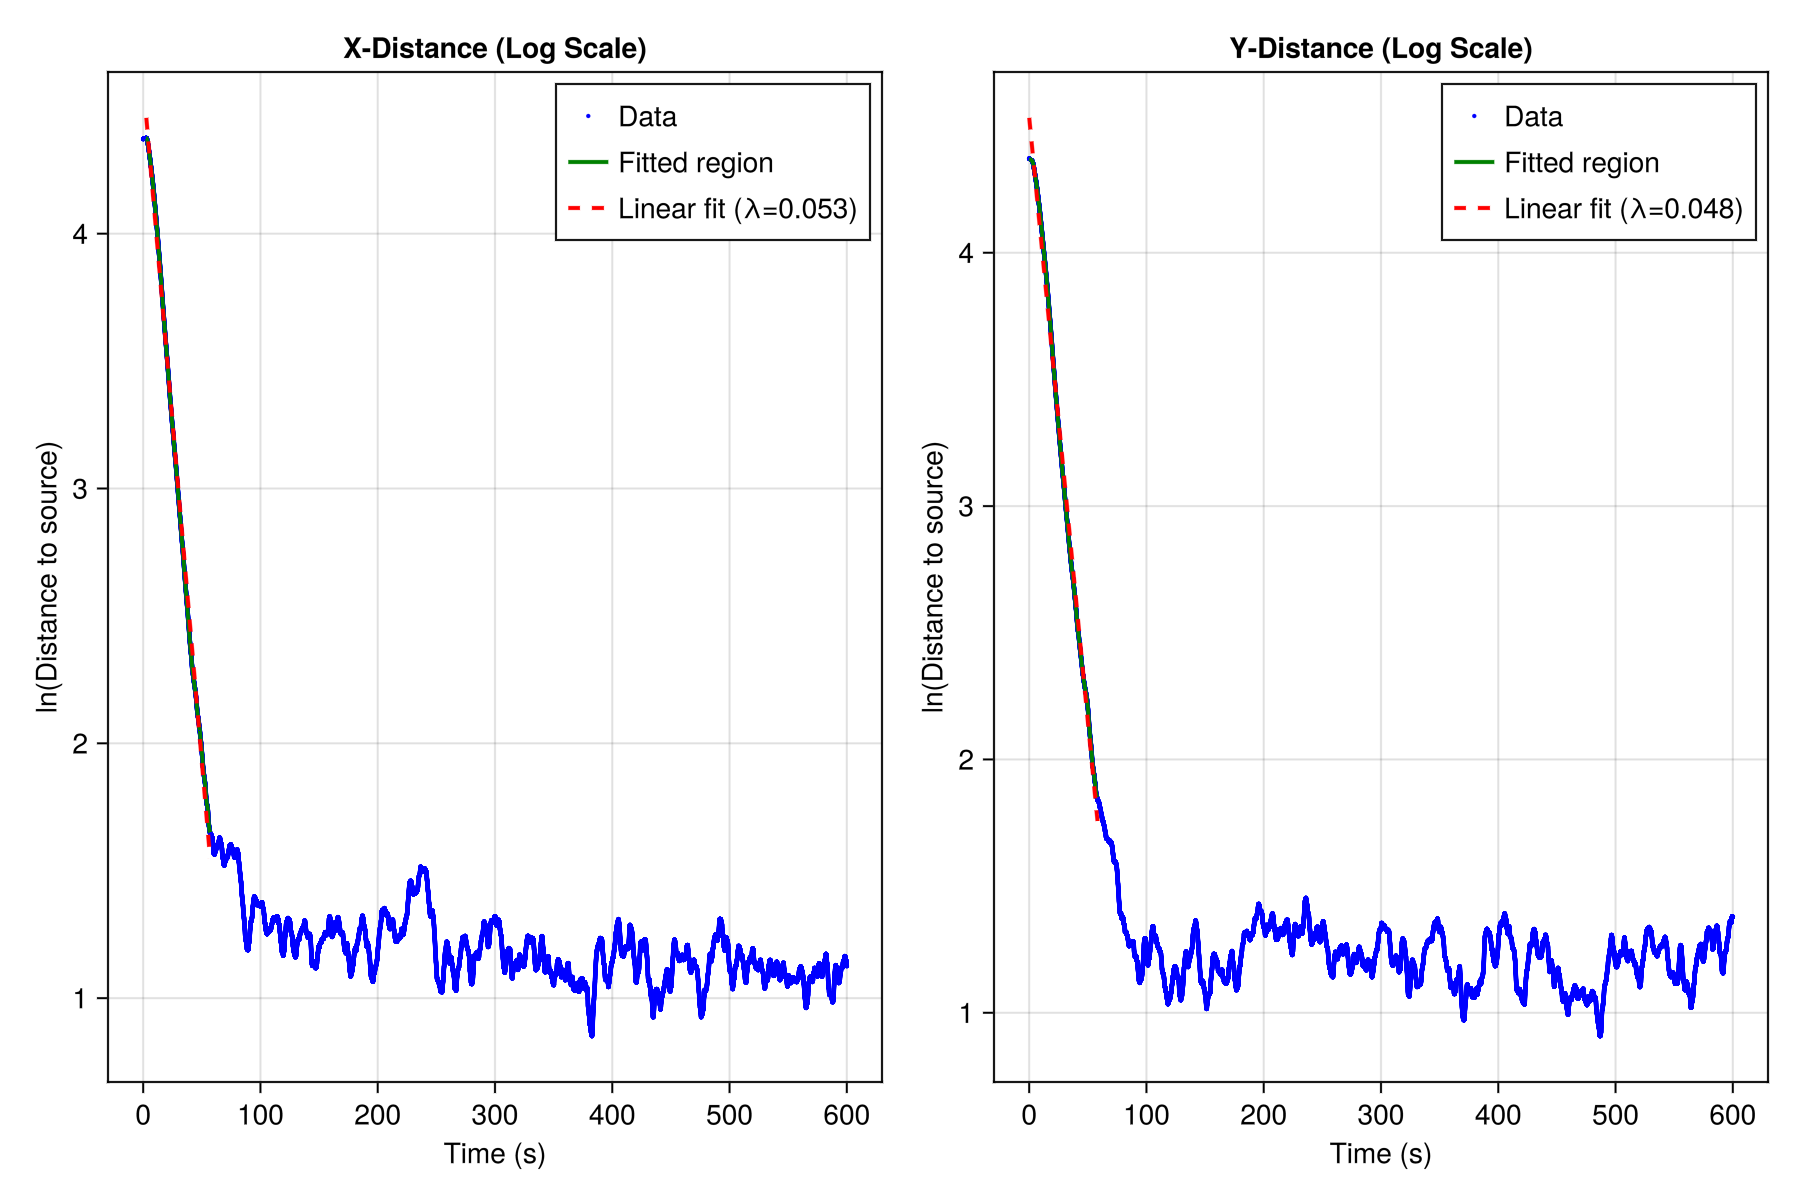

GLMakie.Screen(...)

In [86]:
steps = 60000
mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]

jldopen("fsb_10.0_lambda_1.0.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:1001]

        other_y = g["y"][2:1001]

        dists_x = other_x .- xs
        dists_y = other_y .- ys

        push!(mean_dist_x, mean(dists_x))
        push!(mean_dist_y, mean(dists_y))

    end
end

data_x = abs.(mean_dist_x)
data_y = abs.(mean_dist_y)

log_data_x = log.(data_x)
log_data_y = log.(data_y)

time_vec = (1:steps) * 0.01

start_x, end_x = find_linear_region(time_vec, data_x, log_data_x)
start_y, end_y = find_linear_region(time_vec, data_y, log_data_y)

slope_x, intercept_x = linear_fit(time_vec[start_x:end_x], log_data_x[start_x:end_x])
lambda_x = -slope_x  # λ = -slope

slope_y, intercept_y = linear_fit(time_vec[start_y:end_y], log_data_y[start_y:end_y])
lambda_y = -slope_y

fig_linear = Figure(size=(900, 600))

ax1 = Axis(fig_linear[1, 1], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax1, time_vec, log_data_x, color=:blue, markersize=3, label="Data")
lines!(ax1, time_vec[start_x:end_x], log_data_x[start_x:end_x], 
       color=:green, linewidth=2, label="Fitted region")

# xlims!(ax1, 0, end_x*0.01 + 100)

fitted_line_x = [intercept_x + slope_x * t for t in time_vec]

lines!(ax1, time_vec[start_x:(end_x + 20)], fitted_line_x[start_x:(end_x + 20)], color=:red, linestyle=:dash, 
        linewidth=2, label="Linear fit (λ=$(round(lambda_x, digits=3)))")
ax1.title = "X-Distance (Log Scale)"
axislegend(ax1, position=:rt)


ax2 = Axis(fig_linear[1, 2], xlabel="Time (s)", ylabel="ln(Distance to source)")
scatter!(ax2, time_vec, log_data_y, color=:blue, markersize=3, label="Data")
lines!(ax2, time_vec[start_y:end_y], log_data_y[start_y:end_y], 
       color=:green, linewidth=2, label="Fitted region")


fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
lines!(ax2, time_vec[start_y:(end_y+ 50)], fitted_line_y[start_y:(end_y+ 50)], color=:red, linestyle=:dash, 
       linewidth=2, label="Linear fit (λ=$(round(lambda_y, digits=3)))")
ax2.title = "Y-Distance (Log Scale)"
axislegend(ax2, position=:rt)
# xlims!(ax2, 0, end_y*0.01 + 100)

display(fig_linear)

In [88]:
save("Plots/Fixed_source_model/Lambda_log_linfit_1.png", fig_linear)

📏  Found descent region: steps 378 to 1587


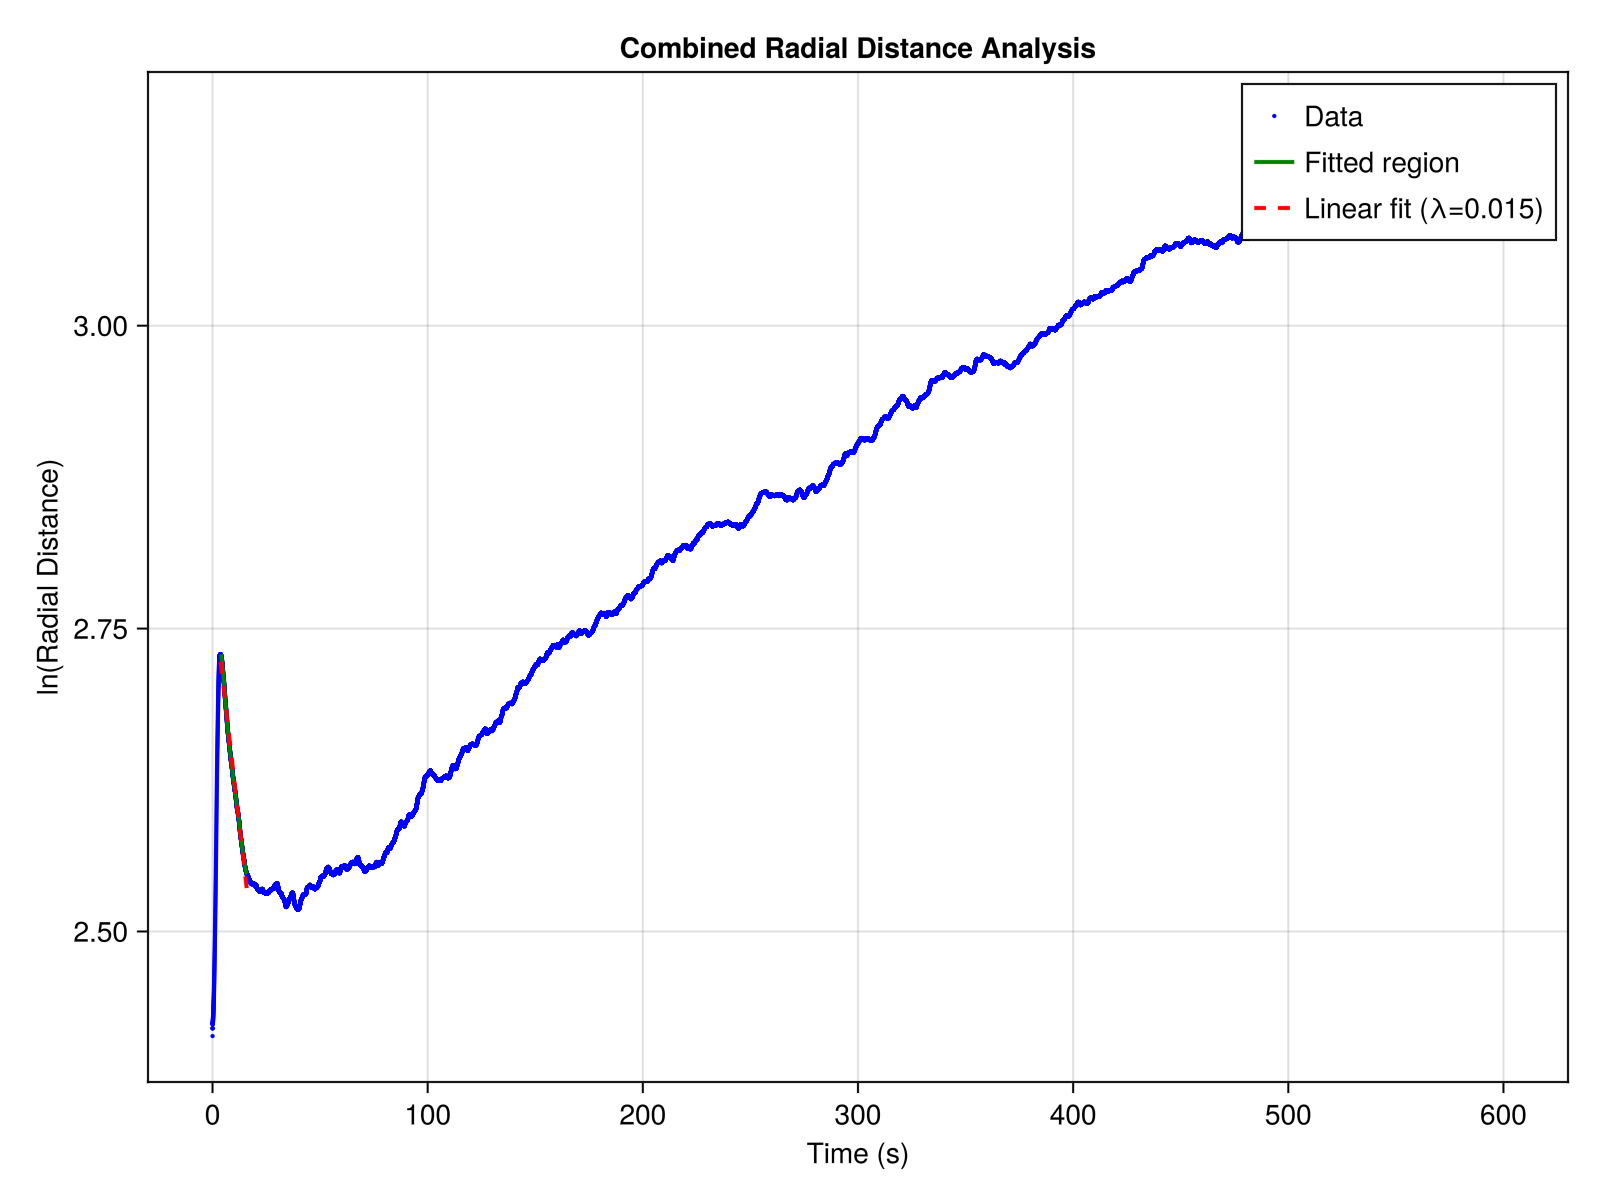

GLMakie.Screen(...)

In [94]:
filename = "fsb_10.0_lambda_5.0.jld2"
steps = 60000
dt = 0.01

# Initialize arrays
mean_dist_r = Float64[] 

# Load data
jldopen(filename, "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        # Source position (cell 1)
        xs = g["x"][1]
        ys = g["y"][1]

        # Other cells (dynamically sized to avoid BoundsError)
        other_x = g["x"][2:end]
        other_y = g["y"][2:end]

        # 1. Calculate displacement vectors
        dx = other_x .- xs
        dy = other_y .- ys

        # 2. Calculate Euclidean distance for each cell: sqrt(dx^2 + dy^2)
        dists_r = sqrt.(dx.^2 .+ dy.^2)

        # 3. Store the mean radial distance for this time step
        push!(mean_dist_r, mean(dists_r))
    end
end

# Pre-processing
# Ensure positive distance (though sqrt ensures this, abs() is safe)
data_r = abs.(mean_dist_r)
log_data_r = log.(data_r)
time_vec = (1:steps) * dt

# --- ANALYSIS (Using your existing functions) ---
# Find the linear region (assuming these functions are defined in your environment)
start_idx, end_idx = find_linear_region(time_vec, data_r, log_data_r)

# Perform linear fit on the log data
slope, intercept = linear_fit(time_vec[start_idx:end_idx], log_data_r[start_idx:end_idx])

# Calculate lambda
k = -slope

# --- PLOTTING ---
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], 
          xlabel="Time (s)", 
          ylabel="ln(Radial Distance)",
          title="Combined Radial Distance Analysis")

# 1. Scatter the raw log data
scatter!(ax, time_vec, log_data_r, color=:blue, markersize=3, label="Data")

# 2. Highlight the fitted region
lines!(ax, time_vec[start_idx:end_idx], log_data_r[start_idx:end_idx], 
       color=:green, linewidth=2, label="Fitted region")

# 3. Plot the full fitted line (extrapolated)
fitted_line = [intercept + slope * t for t in time_vec]
lines!(ax, time_vec[start_idx:end_idx], fitted_line[start_idx:end_idx], color=:red, linestyle=:dash, linewidth=2, 
       label="Linear fit (λ=$(round(k, digits=3)))")

# Add legend
axislegend(ax, position=:rt)

display(fig)

In [95]:
save("Plots/Fixed_source_model/lambda_fit_loglin_5_junts.png", fig)